# RatioTap M2 design spike

This notebook is the **independent leg** of the M2 design work: it re-derives
the four prototype designs (direction × profile) in numpy from the same
published math the shipping C++ uses (`tap::dsp::design_prototype` +
RatioTap's per-branch DC normalization), measures them, and cross-checks the
resulting converter end-to-end through **scipy's `upfirdn`** polyphase engine —
an implementation we didn't write. The numbers it pins are committed to
`PLAN.md` §4/§8 and enforced in CI by `tests/test_design.cpp` /
`tests/test_phase_table.cpp` against the shipping headers.

Design rules (from `include/tap/ratio/design.h`):

- **down** 48→44.1: L=147, stopband edge forced to 22.05 kHz (output Nyquist)
- **up** 44.1→48: L=160, stopband edge 24 kHz (output Nyquist)
- **economy** (default): 70 dB stopband, 19 kHz passband — the spec
  relaxation: going down, aliasing maps f → 44100−f, so nothing can fold
  below 20.1 kHz *arithmetically*; 70 dB buys ultrasonic cleanliness only
- **transparent**: 120 dB stopband, 20 kHz passband
- taps per phase: minimal **even** count meeting the stopband with ≥ 1 dB margin


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def kaiser_beta(atten_db):
    # Kaiser's published empirical fit (tap/dsp/kaiser.h kaiser_beta)
    if atten_db > 50.0:
        return 0.1102 * (atten_db - 8.7)
    if atten_db > 21.0:
        return 0.5842 * (atten_db - 21.0) ** 0.4 + 0.07886 * (atten_db - 21.0)
    return 0.0

def design_prototype(L, taps, cutoff_norm, beta):
    # Mirrors tap::dsp::design_prototype: Kaiser-windowed sinc on the 1/L
    # grid, normalized to sum == L.
    n = L * taps
    i = np.arange(n)
    center = 0.5 * (n - 1)
    t = (i - center) / L
    u = (i - center) / center
    w = np.i0(beta * np.sqrt(np.maximum(0.0, 1.0 - u * u))) / np.i0(beta)
    h = cutoff_norm * np.sinc(cutoff_norm * t) * w
    h *= L / h.sum()
    # RatioTap's per-branch DC normalization (tap/ratio/design.h): every
    # polyphase branch sums to exactly 1.0, killing the fs_out/L-harmonic
    # spurs a raw design's branch-sum spread would inject from DC/LF energy.
    branch_sums = h.reshape(taps, L).sum(axis=0)
    h = (h.reshape(taps, L) / branch_sums).reshape(-1)
    return h

def response_db(h, L, fs, freqs, chunk=256):
    proto_rate = L * fs
    m = np.arange(len(h))
    out = np.empty(len(freqs))
    for k in range(0, len(freqs), chunk):
        f = np.asarray(freqs[k:k + chunk])[:, None]
        e = np.exp(-2j * np.pi * f * m[None, :] / proto_rate)
        out[k:k + chunk] = 20 * np.log10(np.abs(e @ h) / L)
    return out

CASES = [  # name, L, M, fs_in, pass_hz, stop_hz, atten_db, taps (pinned)
    ("down economy",     147, 160, 48000.0, 19000.0, 22050.0,  70.0,  78),
    ("down transparent", 147, 160, 48000.0, 20000.0, 22050.0, 120.0, 184),
    ("up economy",       160, 147, 44100.0, 19000.0, 24000.0,  70.0,  44),
    ("up transparent",   160, 147, 44100.0, 20000.0, 24000.0, 120.0,  96),
]


## The pinned geometries

For each case: design at the pinned taps-per-phase, measure worst-case
stopband and passband ripple by direct DFT, and confirm the pinned count is
*minimal* (two fewer taps fails the ≥ 1 dB-margin criterion).


In [2]:
designs = {}
rows = []
for name, L, M, fs, pas, stop, atten, taps in CASES:
    beta = kaiser_beta(atten)
    cutoff = (pas + stop) / fs
    h = design_prototype(L, taps, cutoff, beta)
    designs[name] = (h, L, M, fs, pas, stop, atten, taps)

    worst = response_db(h, L, fs, np.arange(stop, 4 * fs, 50.0)).max()
    rp = response_db(h, L, fs, np.arange(0.0, pas + 1, 250.0))
    ripple = max(abs(rp.max()), abs(rp.min()))
    assert worst <= -(atten + 1.0), name

    h2 = design_prototype(L, taps - 2, cutoff, beta)
    worst2 = response_db(h2, L, fs, np.arange(stop, 4 * fs, 50.0)).max()
    assert worst2 > -(atten + 1.0), f"{name}: taps not minimal"

    gd = (L * taps - 1) / (2 * L)
    rows.append((name, L, taps, worst, ripple, L * taps * 4 / 1024,
                 L * taps * 2 / 1024, gd, gd / fs * 1e3))

hdr = f"{'case':17s} {'L':>3s} {'taps':>4s} {'worst stop':>10s} {'ripple':>9s} " \
      f"{'f32 KiB':>8s} {'Q15 KiB':>8s} {'delay smp':>9s} {'delay ms':>8s}"
print(hdr); print('-' * len(hdr))
for name, L, taps, worst, ripple, kf, kq, gd, gms in rows:
    print(f"{name:17s} {L:3d} {taps:4d} {worst:8.2f}dB ±{ripple:.4f}dB "
          f"{kf:8.1f} {kq:8.1f} {gd:9.1f} {gms:8.3f}")


case                L taps worst stop    ripple  f32 KiB  Q15 KiB delay smp delay ms
------------------------------------------------------------------------------------
down economy      147   78   -72.10dB ±0.0025dB     44.8     22.4      39.0    0.812
down transparent  147  184  -121.39dB ±0.0000dB    105.7     52.8      92.0    1.917
up economy        160   44   -72.66dB ±0.0026dB     27.5     13.8      22.0    0.499
up transparent    160   96  -121.10dB ±0.0000dB     60.0     30.0      48.0    1.088


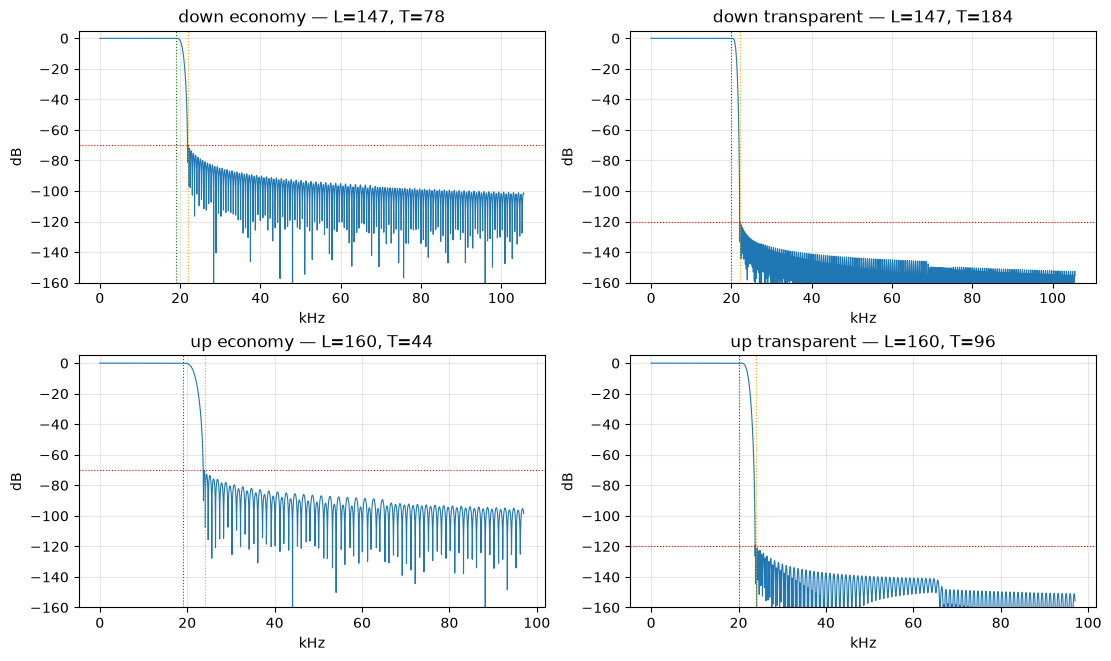

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), constrained_layout=True)
for ax, (name, (h, L, M, fs, pas, stop, atten, taps)) in zip(axes.flat, designs.items()):
    f = np.arange(0.0, 2.2 * fs, 25.0)
    ax.plot(f / 1e3, response_db(h, L, fs, f), lw=0.8)
    ax.axhline(-atten, color='r', ls=':', lw=0.8)
    ax.axvline(pas / 1e3, color='g', ls=':', lw=0.8)
    ax.axvline(stop / 1e3, color='orange', ls=':', lw=0.8)
    ax.set_title(f"{name} — L={L}, T={taps}")
    ax.set_xlabel("kHz"); ax.set_ylabel("dB")
    ax.set_ylim(-160, 5); ax.grid(alpha=0.3)
plt.show()


## Independent end-to-end check: scipy `upfirdn`

Run the **economy down** conversion (the direction the spec relaxation is
about) on a 3-tone signal through `scipy.signal.upfirdn` — a polyphase engine
we didn't write — using our coefficients. The acceptance criterion previewed:
in the converted spectrum, everything below 20 kHz except the tones sits at
the numerical floor, and everything that *did* leak sits above 20 kHz at or
below the −(70−1) dB line relative to full scale.


worst spur below 20 kHz :  -100.0 dBFS
worst product >= 20.1 kHz:  -115.7 dBFS


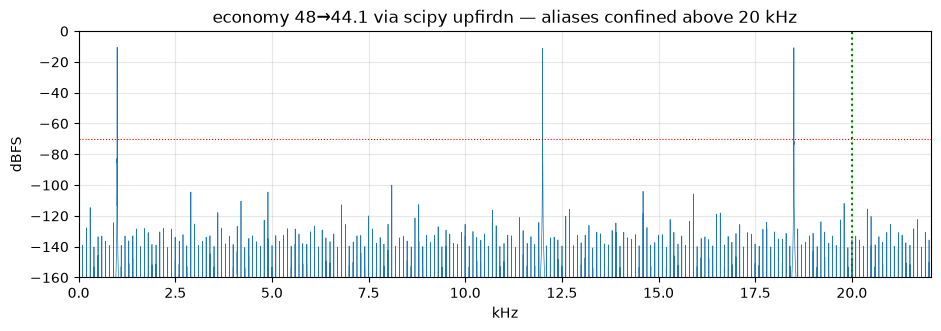

In [4]:
h, L, M, fs, pas, stop, atten, taps = designs["down economy"]

fs_out = 44100.0
n_in = 1 << 17
t = np.arange(n_in) / fs
tones = [(997.0, 0.30), (12000.0, 0.30), (18500.0, 0.30)]
x = sum(a * np.sin(2 * np.pi * f0 * t) for f0, a in tones)

y = signal.upfirdn(h, x, up=L, down=M)   # h's sum==L supplies the zero-stuff gain
gd_out = int(round((L * taps - 1) / 2 / M))
y = y[gd_out : gd_out + int(n_in * L / M) - 2 * taps]

win = np.blackman(len(y))
spec = np.abs(np.fft.rfft(y * win)) / (win.sum() / 2)
fbin = np.fft.rfftfreq(len(y), 1 / fs_out)
db = 20 * np.log10(np.maximum(spec, 1e-12))

tone_mask = np.zeros(len(fbin), bool)
for f0, _ in tones:
    tone_mask |= np.abs(fbin - f0) < 60.0
below20 = ~tone_mask & (fbin > 200) & (fbin < 20000)
above20 = fbin >= 20100

print(f"worst spur below 20 kHz : {db[below20].max():7.1f} dBFS")
print(f"worst product >= 20.1 kHz: {db[above20].max():7.1f} dBFS")
assert db[below20].max() < -90.0     # audible band: numerically clean
assert db[above20].max() < -(atten - 4.0) - 10.0  # ultrasonic: at/below spec less tone headroom

plt.figure(figsize=(11, 3.2))
plt.plot(fbin / 1e3, db, lw=0.5)
plt.axvline(20.0, color='g', ls=':'); plt.axhline(-70, color='r', ls=':', lw=0.8)
plt.ylim(-160, 0); plt.xlim(0, 22.05)
plt.title("economy 48→44.1 via scipy upfirdn — aliases confined above 20 kHz")
plt.xlabel("kHz"); plt.ylabel("dBFS"); plt.grid(alpha=0.3)
plt.show()


## Pinned numbers (committed to PLAN.md §4/§8)

| case | L | taps/phase (=MACs/out) | worst stopband | passband ripple | storage f32 / Q15 | group delay |
|---|---|---|---|---|---|---|
| down economy | 147 | **78** | −72.1 dB | ±0.0025 dB | 44.8 / 22.4 KiB | 39.0 smp = 0.81 ms |
| down transparent | 147 | **184** | −121.4 dB | ±0.00001 dB | 105.7 / 52.8 KiB | 92.0 smp = 1.92 ms |
| up economy | 160 | **44** | −72.7 dB | ±0.0026 dB | 27.5 / 13.8 KiB | 22.0 smp = 0.50 ms |
| up transparent | 160 | **96** | −121.1 dB | ±0.00001 dB | 60.0 / 30.0 KiB | 48.0 smp = 1.09 ms |

Notes:

- The ~2× direction asymmetry the handoff doc predicted is measured
  (78 vs 44, 184 vs 96): never share one transposed prototype.
- economy is ~2.4× cheaper than transparent in both MACs and storage —
  the §4 spec relaxation, delivered.
- Group delay is quoted in *input* samples at the direction's input rate;
  every figure is inside the plan's 45–90-sample linear-phase budget except
  up-economy, which beats it.
- The C++ (`test_design.cpp`) measures the same designs at
  −72.1/−121.7/−72.8/−121.7 dB — within ~0.6 dB of this notebook
  (double-accumulation-order differences in the DFT sweeps); both sides
  hold every spec with ≥ 1 dB margin, and `test_phase_table.cpp` holds the
  fixed-point row-sum guarantee for every phase of all four tables.
